# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

# Basic info
print(df.shape)
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


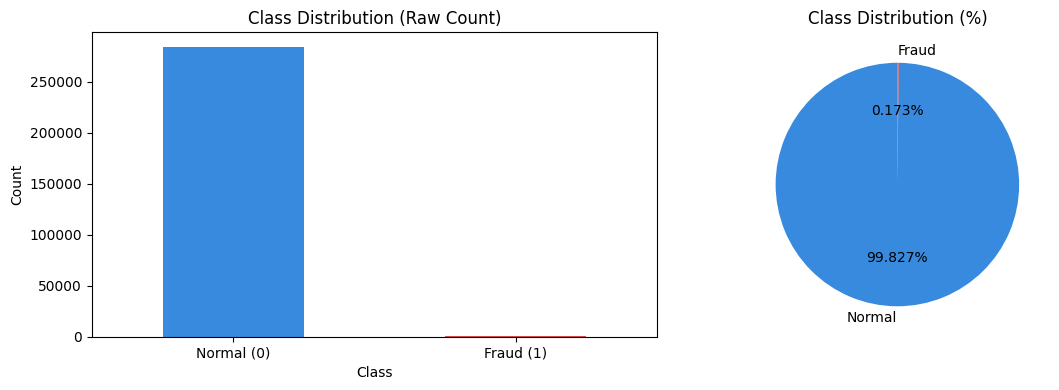

In [5]:
# Visualise class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#378ADD','#E24B4A'])
axes[0].set_title('Class Distribution (Raw Count)')
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(df['Class'].value_counts(), labels=['Normal','Fraud'],
            colors=['#378ADD','#E24B4A'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

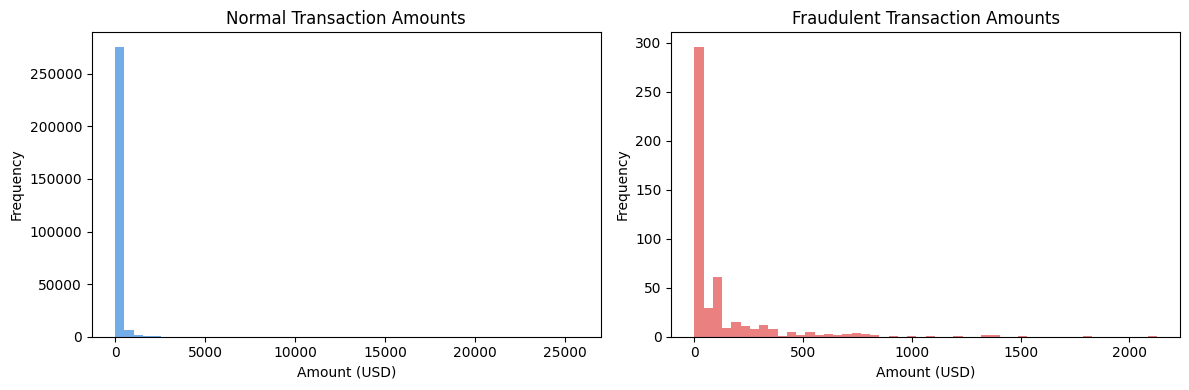

In [6]:
# Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['Class']==0]['Amount'].plot(kind='hist', bins=50, ax=axes[0], color='#378ADD', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount (USD)')

df[df['Class']==1]['Amount'].plot(kind='hist', bins=50, ax=axes[1], color='#E24B4A', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount (USD)')

plt.tight_layout()
plt.savefig('../outputs/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Preprocessing

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale Amount and Time (V1-V28 already scaled by PCA)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original columns
df_clean = df.drop(['Time', 'Amount'], axis=1)

# Split features and target
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Train/test split — stratify to keep fraud % equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape} | Fraud cases: {y_train.sum()}")
print(f"Test set:     {X_test.shape} | Fraud cases: {y_test.sum()}")

Training set: (227845, 30) | Fraud cases: 394
Test set:     (56962, 30) | Fraud cases: 98


# Apply SMOTE (fix the imbalance)

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.1)
# sampling_strategy=0.1 means fraud will be 10% of normal (not 100%)
# This is intentional — over-correcting to 50/50 often hurts performance

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE → Normal: {(y_train==0).sum()}, Fraud: {(y_train==1).sum()}")
print(f"After SMOTE  → Normal: {(y_train_smote==0).sum()}, Fraud: {(y_train_smote==1).sum()}")

Before SMOTE → Normal: 227451, Fraud: 394
After SMOTE  → Normal: 227451, Fraud: 22745


# Model 1: Isolation Forest

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Train on original (unbalanced) data — Isolation Forest is unsupervised
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.002,   # approx fraud rate in dataset
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

# Predict: IsolationForest returns -1 (anomaly) or 1 (normal)
# Convert to 0/1 to match our labels
iso_pred_raw = iso_forest.predict(X_test)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

# Anomaly scores (lower = more anomalous)
iso_scores = -iso_forest.decision_function(X_test)

print("=== Isolation Forest Results ===")
print(classification_report(y_test, iso_pred, target_names=['Normal', 'Fraud']))
print(f"AUC-ROC:  {roc_auc_score(y_test, iso_scores):.4f}")
print(f"AUC-PR:   {average_precision_score(y_test, iso_scores):.4f}")

=== Isolation Forest Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.28      0.35      0.31        98

    accuracy                           1.00     56962
   macro avg       0.64      0.67      0.65     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC:  0.9536
AUC-PR:   0.1916


# Model 2: XGBoost + SMOTE

In [12]:
import xgboost as xgb

# Scale positive weight — tells XGBoost to pay more attention to fraud class
scale = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost + SMOTE Results ===")
print(classification_report(y_test, xgb_pred, target_names=['Normal', 'Fraud']))
print(f"AUC-ROC:  {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"AUC-PR:   {average_precision_score(y_test, xgb_proba):.4f}")

=== XGBoost + SMOTE Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.38      0.86      0.53        98

    accuracy                           1.00     56962
   macro avg       0.69      0.93      0.76     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC:  0.9783
AUC-PR:   0.8391


# Model 3: One-Class SVM (bonus comparison)

In [11]:
from sklearn.svm import OneClassSVM

# Train only on normal transactions
X_train_normal = X_train[y_train == 0]

oc_svm = OneClassSVM(kernel='rbf', nu=0.002, gamma='scale')
oc_svm.fit(X_train_normal)

ocsvm_pred_raw = oc_svm.predict(X_test)
ocsvm_pred     = np.where(ocsvm_pred_raw == -1, 1, 0)
ocsvm_scores   = -oc_svm.decision_function(X_test)

print("=== One-Class SVM Results ===")
print(classification_report(y_test, ocsvm_pred, target_names=['Normal', 'Fraud']))
print(f"AUC-ROC:  {roc_auc_score(y_test, ocsvm_scores):.4f}")
print(f"AUC-PR:   {average_precision_score(y_test, ocsvm_scores):.4f}")

=== One-Class SVM Results ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.14      0.83      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.91      0.61     56962
weighted avg       1.00      0.99      0.99     56962

AUC-ROC:  0.9405
AUC-PR:   0.3817


# Visualise results

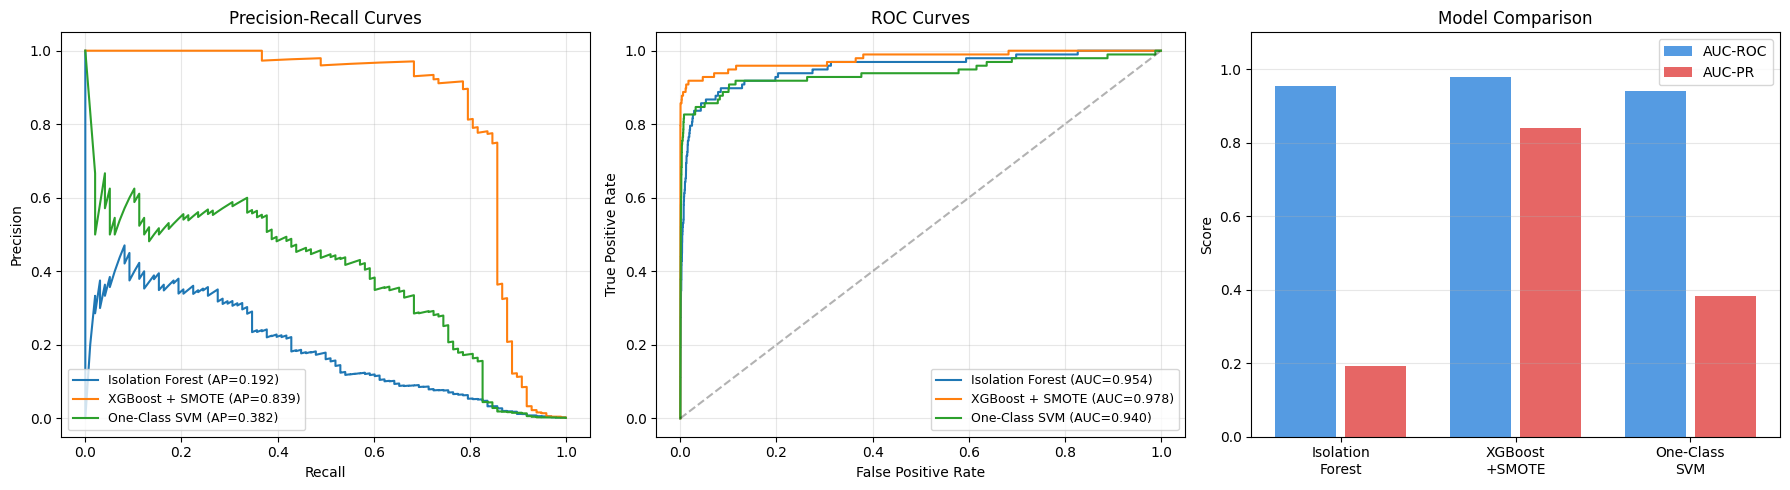

In [13]:
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Precision-Recall Curves ──
for name, scores in [('Isolation Forest', iso_scores),
                     ('XGBoost + SMOTE',  xgb_proba),
                     ('One-Class SVM',    ocsvm_scores)]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    axes[0].plot(recall, precision, label=f'{name} (AP={ap:.3f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Plot 2: ROC Curves ──
for name, scores in [('Isolation Forest', iso_scores),
                     ('XGBoost + SMOTE',  xgb_proba),
                     ('One-Class SVM',    ocsvm_scores)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ── Plot 3: Comparison Bar Chart ──
models  = ['Isolation\nForest', 'XGBoost\n+SMOTE', 'One-Class\nSVM']
auc_roc = [roc_auc_score(y_test, iso_scores),
           roc_auc_score(y_test, xgb_proba),
           roc_auc_score(y_test, ocsvm_scores)]
auc_pr  = [average_precision_score(y_test, iso_scores),
           average_precision_score(y_test, xgb_proba),
           average_precision_score(y_test, ocsvm_scores)]

x = np.arange(len(models))
axes[2].bar(x - 0.2, auc_roc, 0.35, label='AUC-ROC', color='#378ADD', alpha=0.85)
axes[2].bar(x + 0.2, auc_pr,  0.35, label='AUC-PR',  color='#E24B4A', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Model Comparison')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

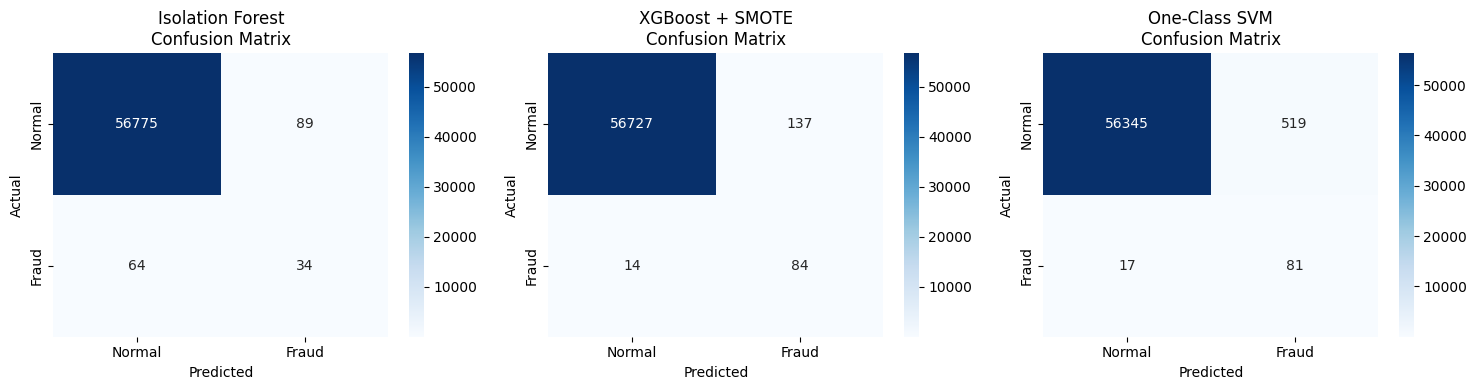

In [14]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, preds, name in zip(axes,
    [iso_pred, xgb_pred, ocsvm_pred],
    ['Isolation Forest', 'XGBoost + SMOTE', 'One-Class SVM']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Fraud'],
                yticklabels=['Normal','Fraud'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary Table

In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = []
for name, preds, scores in [
    ('Isolation Forest', iso_pred,   iso_scores),
    ('XGBoost + SMOTE',  xgb_pred,   xgb_proba),
    ('One-Class SVM',    ocsvm_pred, ocsvm_scores)
]:
    results.append({
        'Model':      name,
        'Precision':  f"{precision_score(y_test, preds, zero_division=0):.4f}",
        'Recall':     f"{recall_score(y_test, preds):.4f}",
        'F1-Score':   f"{f1_score(y_test, preds):.4f}",
        'AUC-ROC':    f"{roc_auc_score(y_test, scores):.4f}",
        'AUC-PR':     f"{average_precision_score(y_test, scores):.4f}",
    })

results_df = pd.DataFrame(results)
print("\n=== Final Model Comparison ===")
print(results_df.to_string(index=False))
results_df.to_csv('../outputs/results_summary.csv', index=False)


=== Final Model Comparison ===
           Model Precision Recall F1-Score AUC-ROC AUC-PR
Isolation Forest    0.2764 0.3469   0.3077  0.9536 0.1916
 XGBoost + SMOTE    0.3801 0.8571   0.5266  0.9783 0.8391
   One-Class SVM    0.1350 0.8265   0.2321  0.9405 0.3817
